# Understanding the Relationship Between Sleep Health, Lifestyle, and Physical Well-being

Submitted by: Roman Hnatyshyn T00228949

# Research Questions:

1. Are there significant differences in sleep health between males and females?
2. What factors have the most influence on sleep quality?
3. Are there notable differences in sleep health across different BMI categories and occupations?
4. What are the best and worst scenarios for sleep quality among Software Engineers?



# Link to the dataset

https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

# Introduction

Sleep plays a crucial role in overall health and well-being, influencing various aspects of physical, mental, and emotional functioning. However, many factors can impact the quality of sleep, including gender, occupation, lifestyle, stress levels, and body weight. Understanding these factors is vital, as poor sleep quality has been linked to a range of health problems, including cardiovascular disease, obesity, diabetes, and mental health disorders.

This project aims to explore the key factors that influence sleep quality, with a particular focus on how variables such as gender, BMI (Body Mass Index), occupation, stress levels, and sleep disorders contribute to sleep health. By analyzing a dataset that includes various demographic and health-related variables, the project seeks to uncover patterns and correlations that can help explain the differences in sleep quality across different populations.

In addition to descriptive analytics, the project uses machine learning techniques, specifically regression models, to predict sleep quality based on these factors. The goal is to create models that can help individuals, particularly those in demanding professions like software engineering, understand the best and worst conditions for achieving optimal sleep. The project also aims to address important research questions regarding the relationship between sleep disorders, stress, BMI, and overall sleep health.

By the end of this analysis, the project will provide insights into how sleep quality can be influenced by various factors and offer predictive models that could be used to improve sleep health for different individuals based on their personal circumstances.

# Importing all needed libraries for the project and reading the file
In this section, I imported all the libraries required for the project. Initially, the imports were scattered throughout the code. However, once I finished writing the entire script, I consolidated all the imports at the beginning of the file to make the code more organized and easier to manage. Additionally, I loaded the dataset using a file path and included a script to handle different encoding techniques for reading the data, as I had encountered issues with dataset encoding in the past.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import LabelEncoder

file_path = '/content/Sleep_health_and_lifestyle_dataset.csv'
try:
    data = pd.read_csv(file_path, encoding='latin1')
    print(data.head())
except UnicodeDecodeError:

    try:
        data = pd.read_csv(file_path, encoding='ISO-8859-1')
        print(data.head())

    except UnicodeDecodeError as e:
        print(e)


   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80          75      

# Data Preprocessing
Upon examining the dataset, I identified some issues that required cleaning. The 'Sleep Disorder' column contained empty rows, which indicated that the person did not have any sleep disorders. To handle this, I replaced all the NaN values with the string 'No' to prevent errors during processing. Additionally, the 'BMI Category' column included both 'Normal' and 'Normal Weight' entries, which referred to the same category. To standardize the data for more efficient processing, I unified all such entries under the label "Normal."

In [4]:
#Replacing NaN and making values with the same meaning the same in "BMI Category" column

data['Sleep Disorder'].fillna('No', inplace=True)

data['BMI Category'] = data['BMI Category'].replace('Normal Weight', 'Normal')

print(data.head())

   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200             No  
1         125/80          75      

<ipython-input-4-f03f0ec4686b>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sleep Disorder'].fillna('No', inplace=True)


I also opted to convert the 'BMI Category' and 'Sleep Disorder' columns into numeric formats to facilitate correlation analysis and machine learning processes. For the 'BMI Category,' I assigned values as follows: 0 for Normal, 1 for Overweight, and 2 for Obese. For the 'Sleep Disorder' column, I simplified it into a binary format: 0 indicating no sleep disorder and 1 indicating the presence of a sleep disorder.

In [5]:
#Preprocess mapping for BMI and Sleep Disorder

bmi_category_mapping = {'Normal': 0, 'Overweight': 1, 'Obese': 2}
data['BMI Category Numeric'] = data['BMI Category'].map(bmi_category_mapping)
data['Sleep Disorder Binary'] = data['Sleep Disorder'].apply(lambda x: 0 if x == 'No' else 1)

# Descriptive Analytics and Statistics
After completing the data preprocessing, I conducted descriptive analytics to gain initial insights and visualize the data. As a starting point, I created bar charts to explore the gender distribution within the dataset, analyzing the number of males and females.

In [6]:
#How many Males and Females are in dataset

gender_counts = data['Gender'].value_counts()

# Output the counts
print(gender_counts)

Gender
Male      189
Female    185
Name: count, dtype: int64


Since the dataset contains an almost equal number of males and females, it is unnecessary to adjust the data for gender proportions. Following this analysis, I explored the distribution of occupations within the dataset to understand the representation of different professional groups.

In [7]:
#How many different occupations are there

occupation_counts = data['Occupation'].value_counts()

# Output the counts
print(occupation_counts)

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


# Differences in Sleep between Male and Female

To explore potential differences in sleep patterns between males and females, I created a series of bar charts to compare various sleep-related factors across genders. Specifically, I analyzed and visualized differences in sleep disorders, stress levels, quality of sleep, and sleep duration for each gender.

<ipython-input-8-b2c100856216>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_sleep_disorder_counts.index, y=gender_sleep_disorder_counts.values, palette=color_map)


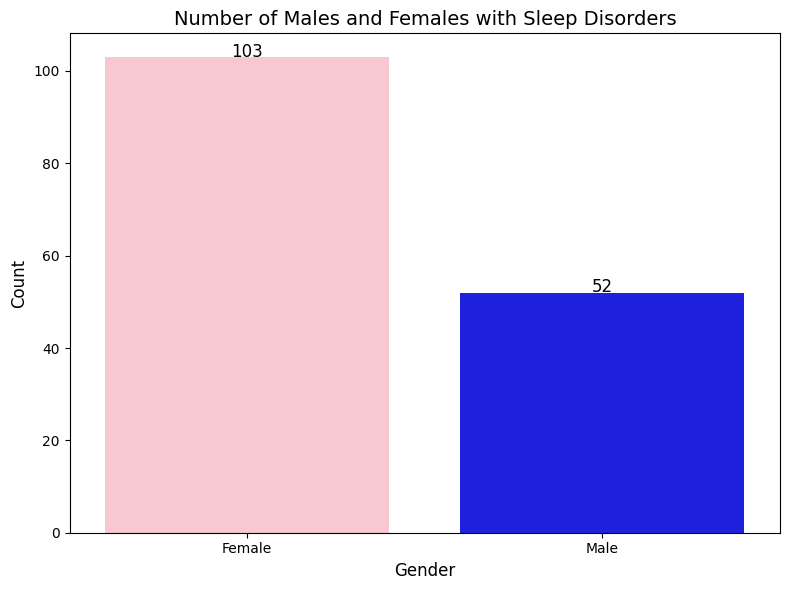

In [8]:
#How many males and females have sleep disorders

sleep_disorder_data = data[data['Sleep Disorder'] != 'No']

# Group by 'Gender' and count how many males and females have sleep disorders
gender_sleep_disorder_counts = sleep_disorder_data['Gender'].value_counts()

color_map = {'Male': 'blue', 'Female': 'pink'}

# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_sleep_disorder_counts.index, y=gender_sleep_disorder_counts.values, palette=color_map)

# Add titles and labels
plt.title('Number of Males and Females with Sleep Disorders', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the counts
for i, value in enumerate(gender_sleep_disorder_counts.values):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

The data revealed that women are twice as likely as men to experience sleep disorders. Initially skeptical, I decided to validate this finding by reviewing articles from reputable medical sources. After exploring various studies and resources, I confirmed that this observation aligns with existing research.

A common explanation is the hormonal fluctuations associated with the menstrual cycle. These fluctuations can disrupt sleep by causing imbalances that lead to sleep disturbances. Additionally, this hormonal imbalance may cause daytime sleepiness, which can tempt individuals to nap. While seemingly harmless, napping can disrupt sleep routines and contribute to sleepless nights.

For further reading and evidence supporting these insights, here are links to related articles:

https://pmc.ncbi.nlm.nih.gov/articles/PMC5760052/

https://www.sleepfoundation.org/women-sleep

https://www.emedicinehealth.com/sleep_disorders_in_women/article_em.htm

I also decided to have a look at sleep quality and sleep duration accross genders.

<ipython-input-9-bf8971956a0e>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Gender', y='Quality of Sleep', data=average_sleep_data_by_gender, color='skyblue', ci=None)


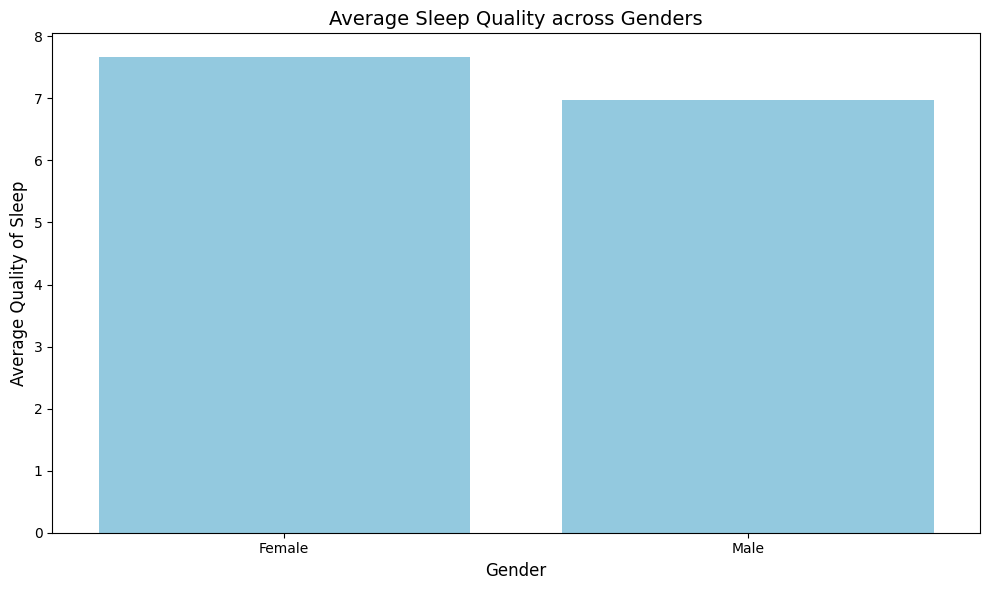

<ipython-input-9-bf8971956a0e>:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Gender', y='Sleep Duration', data=average_sleep_data_by_gender, color='lightgreen', ci=None)


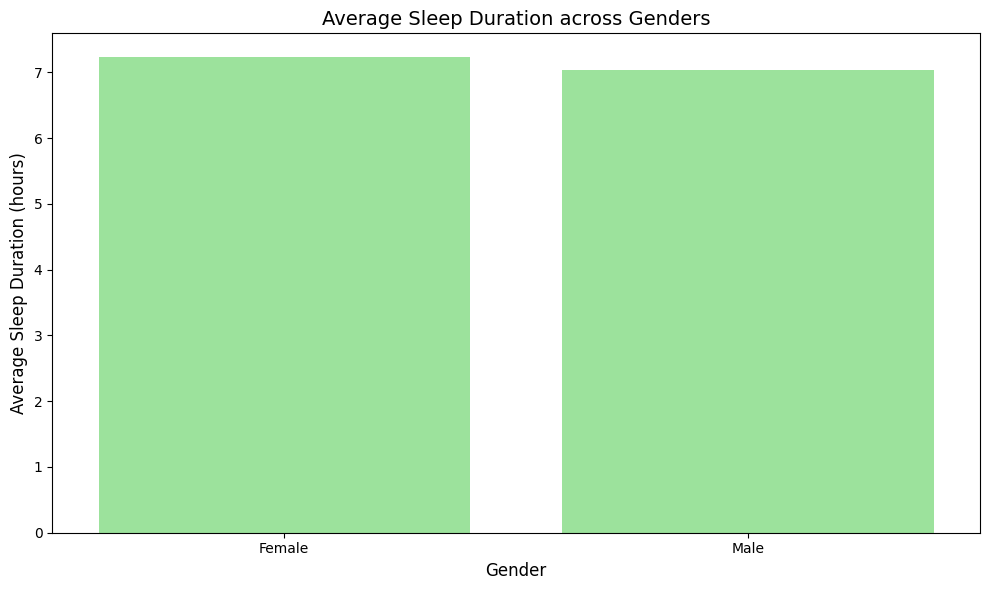

In [9]:
#Sleep Quality and duration depending on gender

# Calculate the average Quality of Sleep and Sleep Duration by Gender
average_sleep_data_by_gender = data.groupby('Gender').agg({
    'Quality of Sleep': 'mean',
    'Sleep Duration': 'mean'
}).reset_index()

# Plot the bar chart for Average Sleep Quality across Genders
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Quality of Sleep', data=average_sleep_data_by_gender, color='skyblue', ci=None)
plt.title('Average Sleep Quality across Genders', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Quality of Sleep', fontsize=12)
plt.tight_layout()
plt.show()

# Plot the bar chart for Average Sleep Duration across Genders
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Sleep Duration', data=average_sleep_data_by_gender, color='lightgreen', ci=None)
plt.title('Average Sleep Duration across Genders', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Sleep Duration (hours)', fontsize=12)
plt.tight_layout()
plt.show()

While the likelihood of having a sleep disorder is twice as high for women compared to men, the data suggests that women have slightly better sleep duration and quality on average.

1. Sleep Duration
Research supports the observation that women generally sleep longer than men, with the average difference ranging from 11 to 15 minutes. This aligns with the dataset, as the bar chart reflects a marginal advantage for women in terms of sleep duration, roughly equivalent to 1/10 of the chart’s division.

2. Sleep Quality
The bar chart also indicates that women experience slightly better sleep quality than men. While this difference is minor in the dataset, external studies provide mixed conclusions. For example:

 - Some studies suggest that poor sleep quality affects 64% of women compared to 36% of men.
 - Others claim the gap is minimal, with a difference of only 1-2%.

The variability in findings often depends on the demographic and timing of the study, as well as the methodology used to collect the data. For reference, here are studies exploring gender differences in sleep quality:

https://www.nature.com/articles/srep43690

https://pmc.ncbi.nlm.nih.gov/articles/PMC5302457/

To deepen my understanding, I examined how stress levels vary between genders and their potential impact on sleep quality.

<ipython-input-10-a71fc5b37db3>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_stress_by_gender.index, y=average_stress_by_gender.values, palette=color_map)


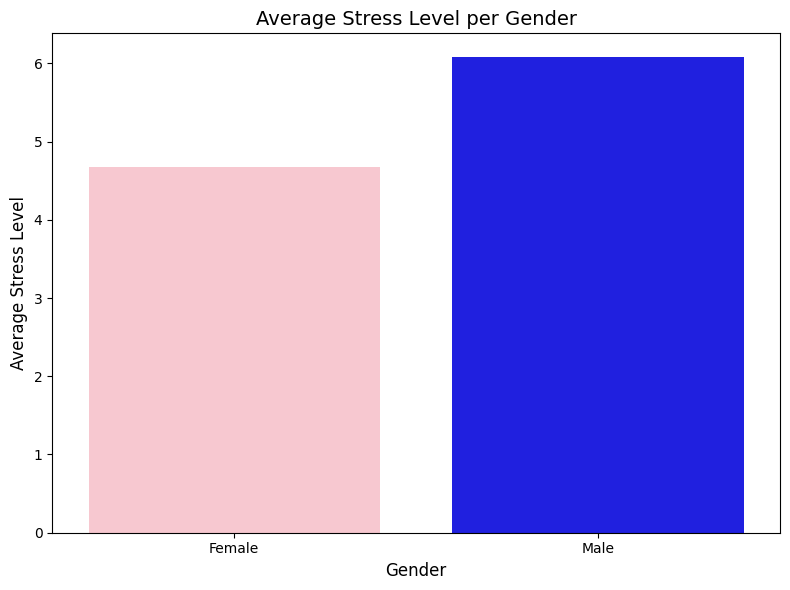

In [10]:
#Stress level per gender

average_stress_by_gender = data.groupby('Gender')['Stress Level'].mean()

color_map = {'Male': 'blue', 'Female': 'pink'}
# Plot the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=average_stress_by_gender.index, y=average_stress_by_gender.values, palette=color_map)

# Add titles and labels
plt.title('Average Stress Level per Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Average Stress Level', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In this dataset, men exhibit higher stress levels compared to women. This difference in stress levels may help explain why women, despite being more prone to sleep disorders, tend to have slightly higher sleep quality. Elevated stress levels are well-documented to negatively impact sleep, potentially disrupting both its duration and quality. Therefore, the lower stress levels among women in the dataset could contribute to their relatively better sleep quality despite their increased susceptibility to sleep disorders.

# Discovering differences between occupations
At this stage, I focused on examining how stress levels, sleep quality, and sleep duration vary across different occupations.

<ipython-input-11-fcfab1f1f7c5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Quality of Sleep', data=data, palette=occupation_color_map)
<ipython-input-11-fcfab1f1f7c5>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Sleep Duration', data=data, palette=occupation_color_map)
<ipython-input-11-fcfab1f1f7c5>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Stress Level', data=data, palette=occupation_color_map)


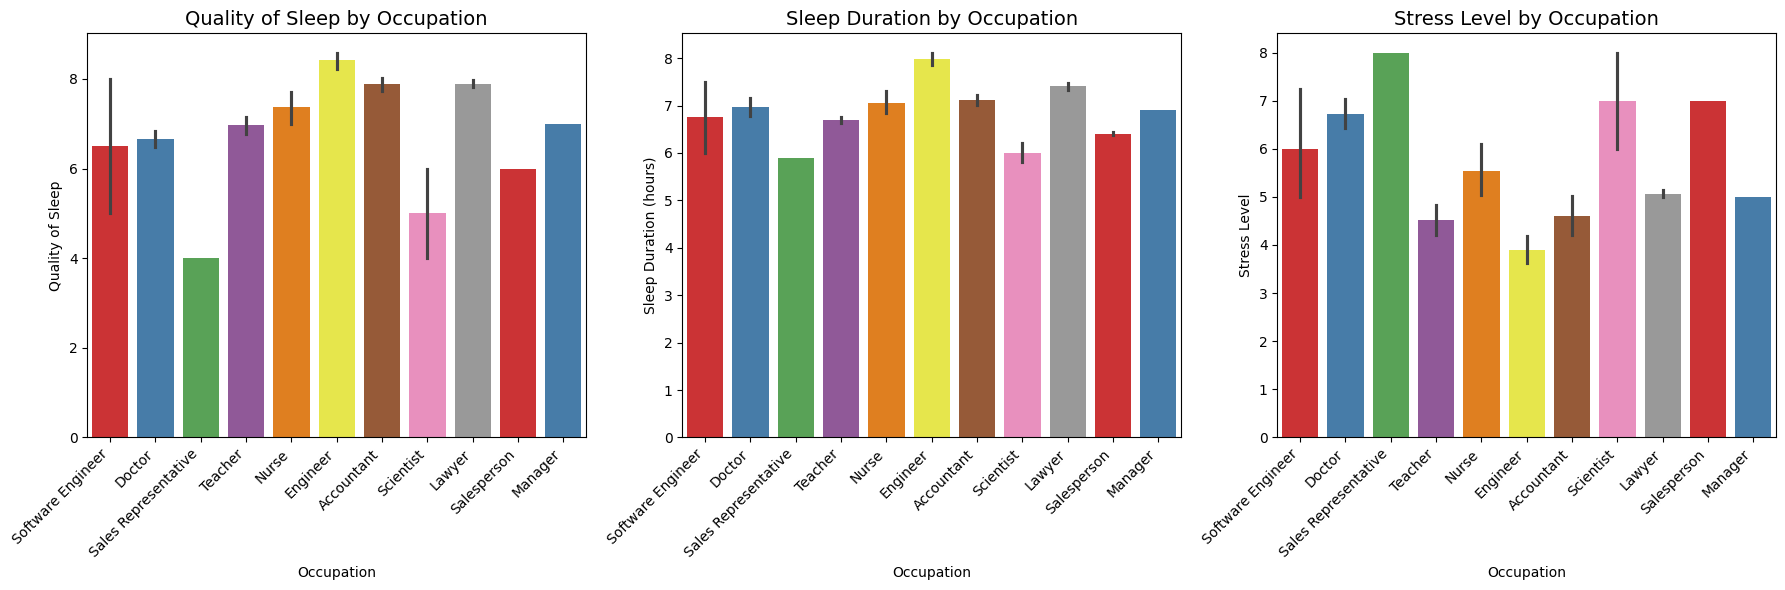

In [11]:
occupations = data['Occupation'].unique()

palette = sns.color_palette("Set1", len(occupations))

occupation_color_map = {occupation: palette[i] for i, occupation in enumerate(occupations)}

plt.figure(figsize=(18, 6))

# 1. Bar chart for Quality of Sleep by Occupation
plt.subplot(1, 3, 1)
sns.barplot(x='Occupation', y='Quality of Sleep', data=data, palette=occupation_color_map)
plt.title('Quality of Sleep by Occupation', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Occupation')
plt.ylabel('Quality of Sleep')

# 2. Bar chart for Sleep Duration by Occupation
plt.subplot(1, 3, 2)
sns.barplot(x='Occupation', y='Sleep Duration', data=data, palette=occupation_color_map)
plt.title('Sleep Duration by Occupation', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Occupation')
plt.ylabel('Sleep Duration (hours)')

# 3. Bar chart for Stress Level by Occupation
plt.subplot(1, 3, 3)
sns.barplot(x='Occupation', y='Stress Level', data=data, palette=occupation_color_map)
plt.title('Stress Level by Occupation', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Occupation')
plt.ylabel('Stress Level')

plt.tight_layout()

plt.show()

After analyzing the bar charts, I gained several important insights. Firstly, I observed that sales representatives have one of the shortest sleep durations, paired with an exceptionally high stress level. These two factors contribute to their low sleep quality, as the combination of insufficient sleep and high stress is a known factor for poor sleep outcomes.

In contrast, when examining the data for Software Engineers, I found that the stress level and sleep quality charts closely mirror each other. Specifically, the values for stress level and sleep quality are very close at the higher and lower ends of the charts. This indicates that there may be a strong correlation between these two variables. As stress increases, sleep quality appears to decrease, supporting the idea that high stress negatively impacts sleep quality, especially in high-stress occupations like software engineering. This suggests that stress management could be an important factor in improving sleep quality for individuals in such professions.

# Sleep Quality and Duration across BMI Categories
I have a friend who is very interested in lifestyle and health, and he often discusses the connections between various factors that may initially seem unrelated. His insights inspired me to explore the relationship between BMI categories and sleep duration and quality. I wanted to investigate whether there are any significant patterns or correlations between a person's body mass index (BMI) and their sleep habits, particularly in terms of sleep duration and quality.

<ipython-input-12-9a3c96eb3b50>:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='BMI Category', y='Quality of Sleep', data=average_sleep_data, color='skyblue', ci=None)


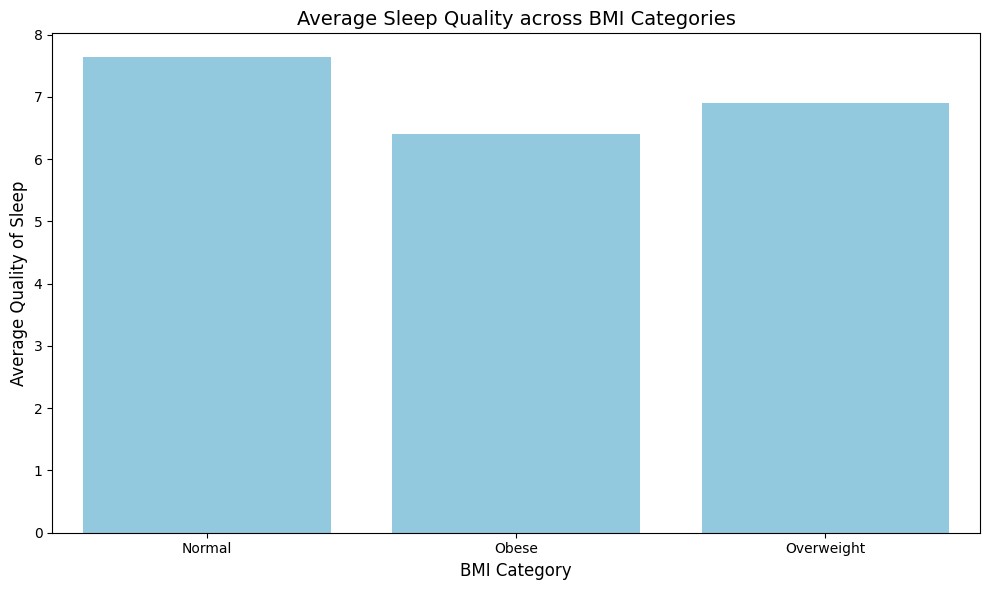

<ipython-input-12-9a3c96eb3b50>:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='BMI Category', y='Sleep Duration', data=average_sleep_data, color='lightgreen', ci=None)


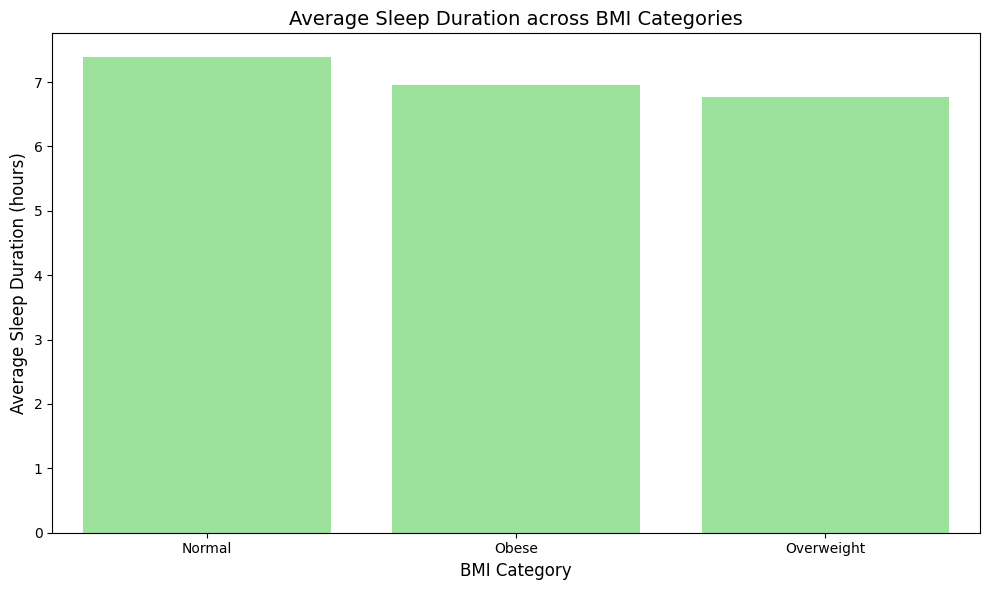

In [12]:
#Sleep Quality and duration across BMI Categories

# Calculate the average Quality of Sleep and Sleep Duration by BMI Category
average_sleep_data = data.groupby('BMI Category').agg({
    'Quality of Sleep': 'mean',
    'Sleep Duration': 'mean'
}).reset_index()

# Plot the bar chart for Average Sleep Quality across BMI Categories
plt.figure(figsize=(10, 6))
sns.barplot(x='BMI Category', y='Quality of Sleep', data=average_sleep_data, color='skyblue', ci=None)
plt.title('Average Sleep Quality across BMI Categories', fontsize=14)
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Average Quality of Sleep', fontsize=12)
plt.tight_layout()
plt.show()

# Plot the bar chart for Average Sleep Duration across BMI Categories
plt.figure(figsize=(10, 6))
sns.barplot(x='BMI Category', y='Sleep Duration', data=average_sleep_data, color='lightgreen', ci=None)
plt.title('Average Sleep Duration across BMI Categories', fontsize=14)
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Average Sleep Duration (hours)', fontsize=12)
plt.tight_layout()
plt.show()

After creating these charts, I realized that body weight plays a significant role when it comes to sleep health. Initially, I was skeptical—if you live a lifestyle similar to someone with a normal weight, how could it possibly affect your sleep quality? To explore this, I began reading articles on the topic. Many studies conclude that short sleep duration and poor sleep quality are indeed associated with overweight and obesity, particularly among young adults. Therefore, BMI categories should likely correlate with sleep quality. Researchers suggest that obesity may disrupt metabolism and/or sleep-wake cycles in ways that negatively impact sleep quality. Additionally, the physical effects of carrying excess weight can directly influence sleep quality.

Sources:

https://pmc.ncbi.nlm.nih.gov/articles/PMC9480680/

https://www.sleepfoundation.org/physical-health/obesity-and-sleep







# Correlations

Ultimately, the most important step is to identify the correlations in order to determine the factors that have the greatest impact on sleep quality.




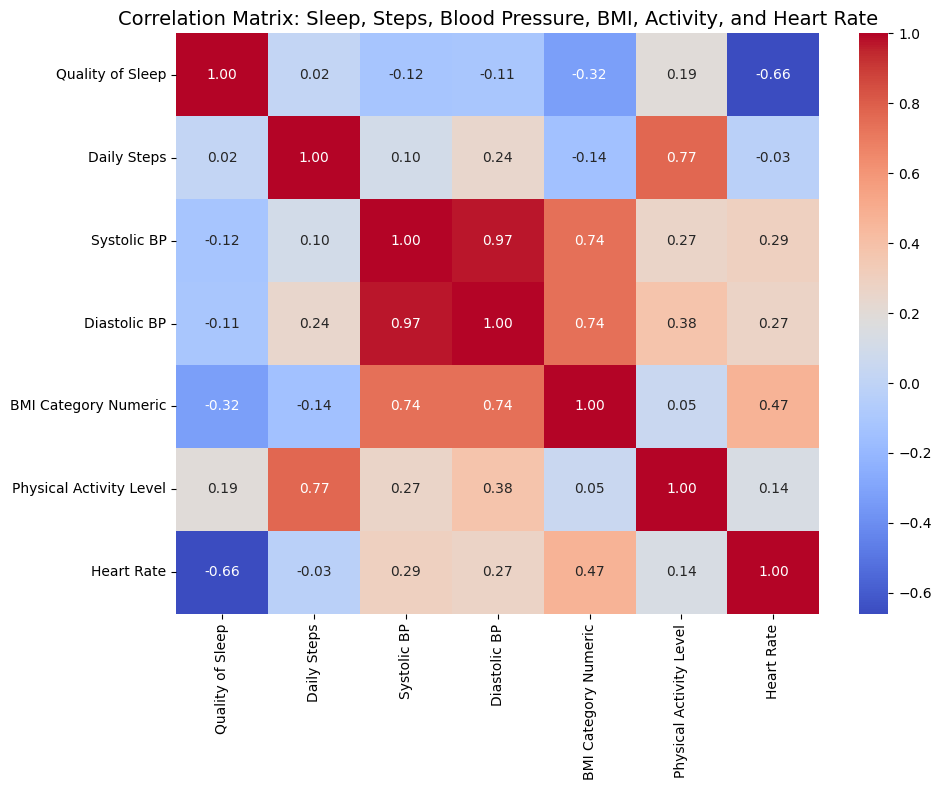

In [13]:
# Ensure the columns are numeric and include Diastolic BP

data[['Systolic BP', 'Diastolic BP']] = data['Blood Pressure'].str.split('/', expand=True)

# Select relevant columns for correlation
correlation_data = data[['Quality of Sleep', 'Daily Steps', 'Systolic BP', 'Diastolic BP',
                         'BMI Category Numeric', 'Physical Activity Level', 'Heart Rate']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix: Sleep, Steps, Blood Pressure, BMI, Activity, and Heart Rate', fontsize=14)
plt.tight_layout()
plt.show()


This correlation matrix reveals that heart rate and BMI Category have the strongest influence on sleep quality compared to other variables (in exact this matrix). To clarify, the correlation matrix shows how one variable affects another. The closer the number is to 1 or -1, the stronger the correlation. For instance, if we examine the relationship between heart rate and sleep quality, the value at their intersection is -0.66. This indicates that as heart rate increases, the quality of sleep tends to decrease. From this, I realized that not only stress level, sleep duration, and sleep disorders impact sleep quality, but heart rate and BMI also play a significant role. As a result, I decided to create another correlation matrix focusing solely on the variables most strongly correlated with sleep quality.

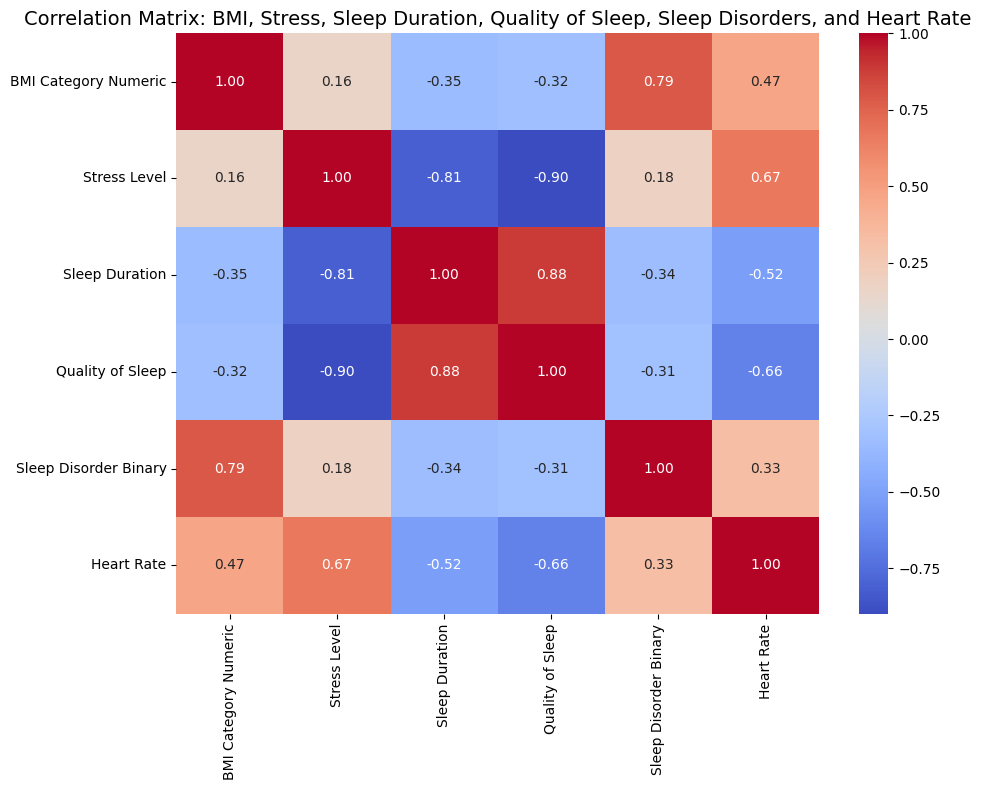

In [14]:
# Select relevant columns for correlation, now including Heart Rate
correlation_data = data[['BMI Category Numeric', 'Stress Level', 'Sleep Duration', 'Quality of Sleep',
                         'Sleep Disorder Binary', 'Heart Rate']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Plot the heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix: BMI, Stress, Sleep Duration, Quality of Sleep, Sleep Disorders, and Heart Rate', fontsize=14)
plt.tight_layout()
plt.show()

This correlation matrix confirmed the predictions I made after my previous research. Sleep duration and stress level show the strongest correlations with sleep quality, at 0.88 and -0.90, respectively. BMI category and sleep disorder are also strongly correlated with each other (0.79), which aligns with several studies, including those I referenced in the section on BMI category, indicating that higher BMI increases the likelihood of conditions like sleep apnea or insomnia. This correlation matrix helped me identify the key variables to use in my prediction models.

# Regression
Initially, I decided to build a regression model to predict sleep quality using the columns related directly to sleep: sleep disorder, sleep duration, and stress level. These factors seemed to have the most immediate connection to sleep quality. I also planned to create a second regression model incorporating heart rate and BMI category to compare the differences in prediction quality.

Regression Coefficients:
Sleep Duration Coefficient: 0.65
Stress Level Coefficient: -0.36
Sleep Disorder Coefficient: -0.15
Intercept: 4.67

Model Evaluation:
R-squared: 0.88
Mean Squared Error: 0.19


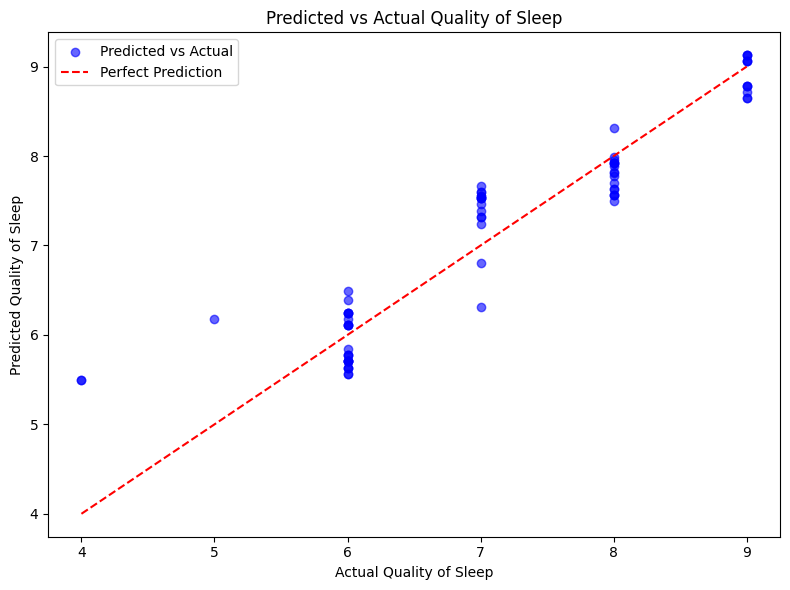


Feature Importance (Normalized):
Sleep Duration: 0.56
Stress Level: 0.31
Sleep Disorder: 0.13


In [15]:
X = data[['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary']]
y = data['Quality of Sleep']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r_squared = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Regression Coefficients:")
print(f"Sleep Duration Coefficient: {model.coef_[0]:.2f}")
print(f"Stress Level Coefficient: {model.coef_[1]:.2f}")
print(f"Sleep Disorder Coefficient: {model.coef_[2]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

print("\nModel Evaluation:")
print(f"R-squared: {r_squared:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

# Visualize predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Quality of Sleep')
plt.ylabel('Predicted Quality of Sleep')
plt.title('Predicted vs Actual Quality of Sleep')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance (optional)
normalized_coefficients = np.abs(model.coef_) / np.sum(np.abs(model.coef_))
print("\nFeature Importance (Normalized):")
print(f"Sleep Duration: {normalized_coefficients[0]:.2f}")
print(f"Stress Level: {normalized_coefficients[1]:.2f}")
print(f"Sleep Disorder: {normalized_coefficients[2]:.2f}")


The results are promising. The regression graph shows that the model performs well, as the blue data points are closely aligned with the ideal prediction line. However, the model struggles to predict sleep quality at lower levels, as the points deviate farther from the line. On the other hand, the model performs more accurately for higher sleep quality predictions. Despite this, the regression model remains effective overall.

Next, I decided to incorporate heart rate and BMI category into the regression model to see how the predictions would change.

Regression Coefficients:
Sleep Duration Coefficient: 0.66
Stress Level Coefficient: -0.33
Sleep Disorder Coefficient: -0.06
BMI Category Coefficient: -0.07
Heart Rate Coefficient: -0.02
Intercept: 5.66

Model Evaluation:
R-squared: 0.89
Mean Squared Error: 0.16


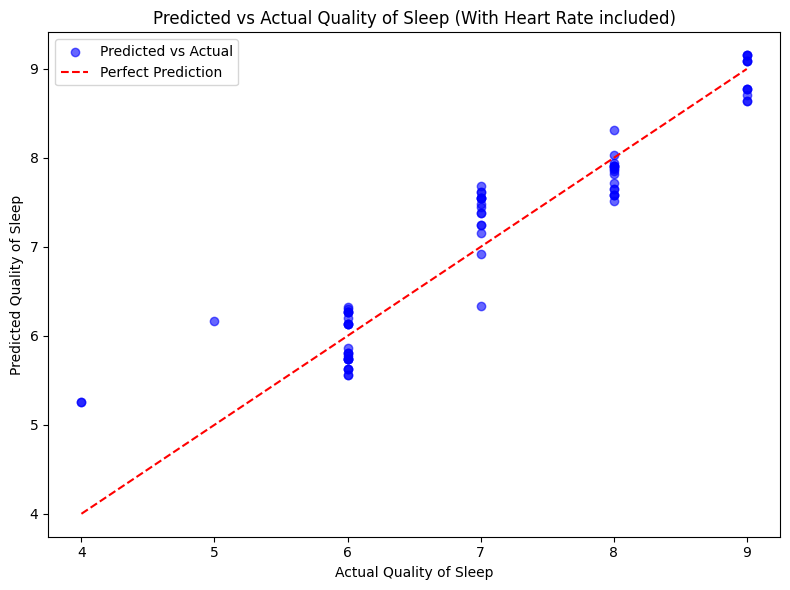


Feature Importance (Normalized):
Sleep Duration: 0.58
Stress Level: 0.29
Sleep Disorder: 0.05
BMI Category: 0.06
Heart Rate: 0.02


In [16]:
X = data[['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', 'Heart Rate']]
y = data['Quality of Sleep']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r_squared = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Regression Coefficients:")
print(f"Sleep Duration Coefficient: {model.coef_[0]:.2f}")
print(f"Stress Level Coefficient: {model.coef_[1]:.2f}")
print(f"Sleep Disorder Coefficient: {model.coef_[2]:.2f}")
print(f"BMI Category Coefficient: {model.coef_[3]:.2f}")
print(f"Heart Rate Coefficient: {model.coef_[4]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

print("\nModel Evaluation:")
print(f"R-squared: {r_squared:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

# Visualize predicted vs actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Quality of Sleep')
plt.ylabel('Predicted Quality of Sleep')
plt.title('Predicted vs Actual Quality of Sleep (With Heart Rate included)')
plt.legend()
plt.tight_layout()
plt.show()

# Feature importance (optional)
normalized_coefficients = np.abs(model.coef_) / np.sum(np.abs(model.coef_))
print("\nFeature Importance (Normalized):")
print(f"Sleep Duration: {normalized_coefficients[0]:.2f}")
print(f"Stress Level: {normalized_coefficients[1]:.2f}")
print(f"Sleep Disorder: {normalized_coefficients[2]:.2f}")
print(f"BMI Category: {normalized_coefficients[3]:.2f}")
print(f"Heart Rate: {normalized_coefficients[4]:.2f}")

Here, we can see that the model has improved. Some of the blue dots have become less scattered and are closer to the dashed line. However, the feature importance of sleep disorder and stress level has decreased, which slightly differs from the correlation results. This suggests that while the model has become more accurate with the addition of heart rate and BMI category, the relative impact of other variables has shifted.

Explanation of the code for regressions:

1. Defining Predictors and Target:
- The predictors (independent variables) were selected as 'Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', and 'Heart Rate', while the target variable (dependent variable) was the 'Quality of Sleep'. These variables were chosen based on their relevance to sleep quality, as identified in prior steps.

2. Splitting the Data:
- The dataset was split into training and testing sets using train_test_split(). The training set was used to fit the regression model, while the testing set was used to evaluate its performance. This split helps ensure that the model generalizes well to unseen data.

3. Training the Model:
- A linear regression model was chosen to predict the 'Quality of Sleep'. The model was trained on the predictors using the model.fit() function.

4. Making Predictions:
- After training, the model was used to predict the quality of sleep on the testing set (y_pred). The predicted values were then compared to the actual values from the testing set to evaluate model performance.

5. Evaluating the Model:
- The model's performance was assessed using two metrics:

 - R-squared: A measure of how well the independent variables explain the variability in the dependent variable. A higher R-squared value indicates a better fit.
 - Mean Squared Error (MSE): This measures the average squared difference between the actual and predicted values. Lower MSE values indicate a better model.
6. Visualizing Predictions:
- A scatter plot was created to visualize the relationship between the predicted and actual values. A perfect prediction would lie on the dashed red line, and the plot shows how close the predicted values are to this line. The closer the dots are to the line, the better the model's predictions.

7. Feature Importance:
- Feature importance was calculated by normalizing the model's coefficients. This highlights which predictors have the most influence on the quality of sleep. A higher normalized coefficient indicates a stronger impact on the target variable.

Regression Based on Stress Level, Sleep Disorders, and Sleep Duration
In this case, a simpler regression model was created using only three predictors: 'Sleep Duration', 'Stress Level', and 'Sleep Disorder Binary'.



# Decision Tree with user inputs

At this stage, I decided to implement algorithms using a decision tree model. To make the process more engaging, I incorporated user input to predict the quality of sleep.

In [19]:
# Step 1: Load and Prepare the Dataset
file_path = '/content/Sleep_health_and_lifestyle_dataset.csv'
sleep_data = pd.read_csv(file_path)

sleep_data['Sleep Disorder'].fillna('No', inplace=True)

sleep_data['BMI Category'] = sleep_data['BMI Category'].replace('Normal Weight', 'Normal')

# Map Quality of Sleep into categories
def categorize_quality(sleep_quality):
    if sleep_quality <= 3:
        return 'Bad Sleep'
    elif 4 <= sleep_quality <= 6:
        return 'Mid Sleep'
    else:
        return 'Good Sleep'

sleep_data['Sleep Category'] = sleep_data['Quality of Sleep'].apply(categorize_quality)

# Pre-calculate average stress level per occupation
avg_stress_by_occupation = sleep_data.groupby('Occupation')['Stress Level'].mean().to_dict()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure', 'Sleep Disorder']

for column in categorical_columns:
    le = LabelEncoder()
    sleep_data[column] = le.fit_transform(sleep_data[column])
    label_encoders[column] = le

# Step 2: Define Features and Target
X = sleep_data.drop(columns=['Person ID', 'Quality of Sleep', 'Sleep Category', 'Stress Level'])
y = sleep_data['Sleep Category']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train the Decision Tree Model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 4: Define the Interactive Prediction Function
# Step 4: Define the Interactive Prediction Function
def predict_sleep_quality_interactive(clf, label_encoders, avg_stress_by_occupation):

    print("\n--- Predict Sleep Quality ---")
    print("Please provide the following details. Enter valid inputs where applicable.\n")

    try:
        # Input prompts for each parameter
        gender = input("Gender (Male/Female): ").strip().capitalize()
        age = int(input("Age (e.g., 25): ").strip())
        occupation = input(f"Select Occupation (Options: {', '.join(avg_stress_by_occupation.keys())}): ").strip()

        # Capitalize the first letter of each word in occupation for proper matching
        occupation = ' '.join([word.capitalize() for word in occupation.split()])

        # Ensure occupation formatting matches dataset
        if occupation not in avg_stress_by_occupation:
            raise KeyError(f"Occupation '{occupation}' is not recognized.")

        sleep_duration = float(input("Sleep Duration (hours, e.g., 6.5): ").strip())
        bmi_category = input("BMI Category (Normal/Overweight/Obese): ").strip().capitalize()
        blood_pressure = input("Blood Pressure (e.g., 120/80): ").strip()
        heart_rate = int(input("Heart Rate (bpm, e.g., 70): ").strip())
        daily_steps = int(input("Daily Steps (e.g., 8000): ").strip())
        sleep_disorder = input("Sleep Disorder (No/Sleep Apnea/Other): ").strip().capitalize()

        # Determine stress level from occupation
        stress_level = avg_stress_by_occupation.get(occupation, 0)

        # Encoding categorical variables
        gender_encoded = label_encoders['Gender'].transform([gender])[0]
        occupation_encoded = label_encoders['Occupation'].transform([occupation])[0]
        bmi_category_encoded = label_encoders['BMI Category'].transform([bmi_category])[0]
        blood_pressure_encoded = label_encoders['Blood Pressure'].transform([blood_pressure])[0]
        sleep_disorder_encoded = label_encoders['Sleep Disorder'].transform([sleep_disorder])[0]

        # Combine inputs into a feature vector
        features = np.array([[gender_encoded, age, occupation_encoded, sleep_duration, stress_level,
                              bmi_category_encoded, blood_pressure_encoded,
                              heart_rate, daily_steps, sleep_disorder_encoded]])

        # Predict the sleep quality
        prediction = clf.predict(features)[0]

        # Display the result
        print(f"\nPredicted Sleep Quality: {prediction}")

    except KeyError as e:
        print(f"\nError: Invalid input for {e}. Please check your inputs and try again.")
    except ValueError as e:
        print(f"\nError: {e}. Ensure numeric inputs where required and try again.")
    except Exception as e:
        print(f"\nUnexpected error: {e}. Please check your inputs.")

# Step 5: Call the Function for Prediction
predict_sleep_quality_interactive(clf, label_encoders, avg_stress_by_occupation)


<ipython-input-19-811927695060>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sleep_data['Sleep Disorder'].fillna('No', inplace=True)



--- Predict Sleep Quality ---
Please provide the following details. Enter valid inputs where applicable.

Gender (Male/Female): Male
Age (e.g., 25): 20
Select Occupation (Options: Accountant, Doctor, Engineer, Lawyer, Manager, Nurse, Sales Representative, Salesperson, Scientist, Software Engineer, Teacher): Software Engineer
Sleep Duration (hours, e.g., 6.5): 6.7
BMI Category (Normal/Overweight/Obese): Obese
Blood Pressure (e.g., 120/80): 120/80
Heart Rate (bpm, e.g., 70): 60
Daily Steps (e.g., 8000): 4200
Sleep Disorder (No/Sleep Apnea/Other): No

Predicted Sleep Quality: Mid Sleep


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Unfortunately, I had to reload the file and reformat the data, as the algorithm needs to drop columns from the existing dataset (it is better to provide it with fresh data). I categorized the sleep quality into three groups: "bad" (1-3), "mid" (4-6), and "good" (7-10). In hindsight, this was a mistake, as the dataset does not contain any records for "bad" sleep quality (the minimum is 4, which is categorized as "mid"). In the future, I would divide the range into smaller sections to enhance the algorithm's accuracy. This devision is not really good because there is no data, which shows conditions for person having bad sleep quality, so it is imposible to predict consequences for that.

Additionally, I relied solely on text inputs, but it would have been more user-friendly and visually appealing to use dropdown selection boxes. However, I worked with what was feasible in the notebook. As some columns, such as Stress Level, are impossible for the user to know, I decided to take the average stress level for each occupation entered by the user. This decision was made after revisiting the bar charts and analyzing the data.

So what exactly the code does?

1. Features (X) include variables related to user demographics, health, and lifestyle, excluding irrelevant or target-specific columns (e.g., 'Person ID', 'Sleep Category').
The target (y) is set to 'Sleep Category', the categorized quality of sleep.

2. Divides the dataset into training (70%) and testing (30%) subsets using train_test_split. This allows the model to be trained on one set of data and evaluated on another, reducing overfitting.

3. A Decision Tree Classifier is initialized and trained on the training data (X_train, y_train). This model learns patterns in the data to predict sleep quality categories.

4. Collects information about the user's demographics, health, and lifestyle (e.g., gender, age, occupation, sleep duration, BMI category, blood pressure, daily steps, sleep disorder status).
Ensures the inputs are properly formatted and valid (e.g., gender is capitalized, numeric inputs are converted appropriately).

5. Dynamically retrieves the average stress level for the user’s occupation from the pre-calculated dictionary. If the occupation is unrecognized, an error is raised.

6. Converts categorical user inputs (e.g., 'Gender', 'Occupation', 'BMI Category') into numeric values using the previously fitted LabelEncoder instances.

7. Combines all user-provided inputs into a single feature vector. This vector is passed to the trained Decision Tree model to predict the sleep quality category ('Bad Sleep', 'Mid Sleep', or 'Good Sleep').

8. Outputs the predicted sleep quality to the user in a clear and understandable format.

9. Implements robust error handling to catch issues like invalid inputs (e.g., incorrect category names, non-numeric values) or unexpected conditions, providing helpful feedback to the user.

Decision Tree created by this model after it analysed the patterns for different sleep categories:
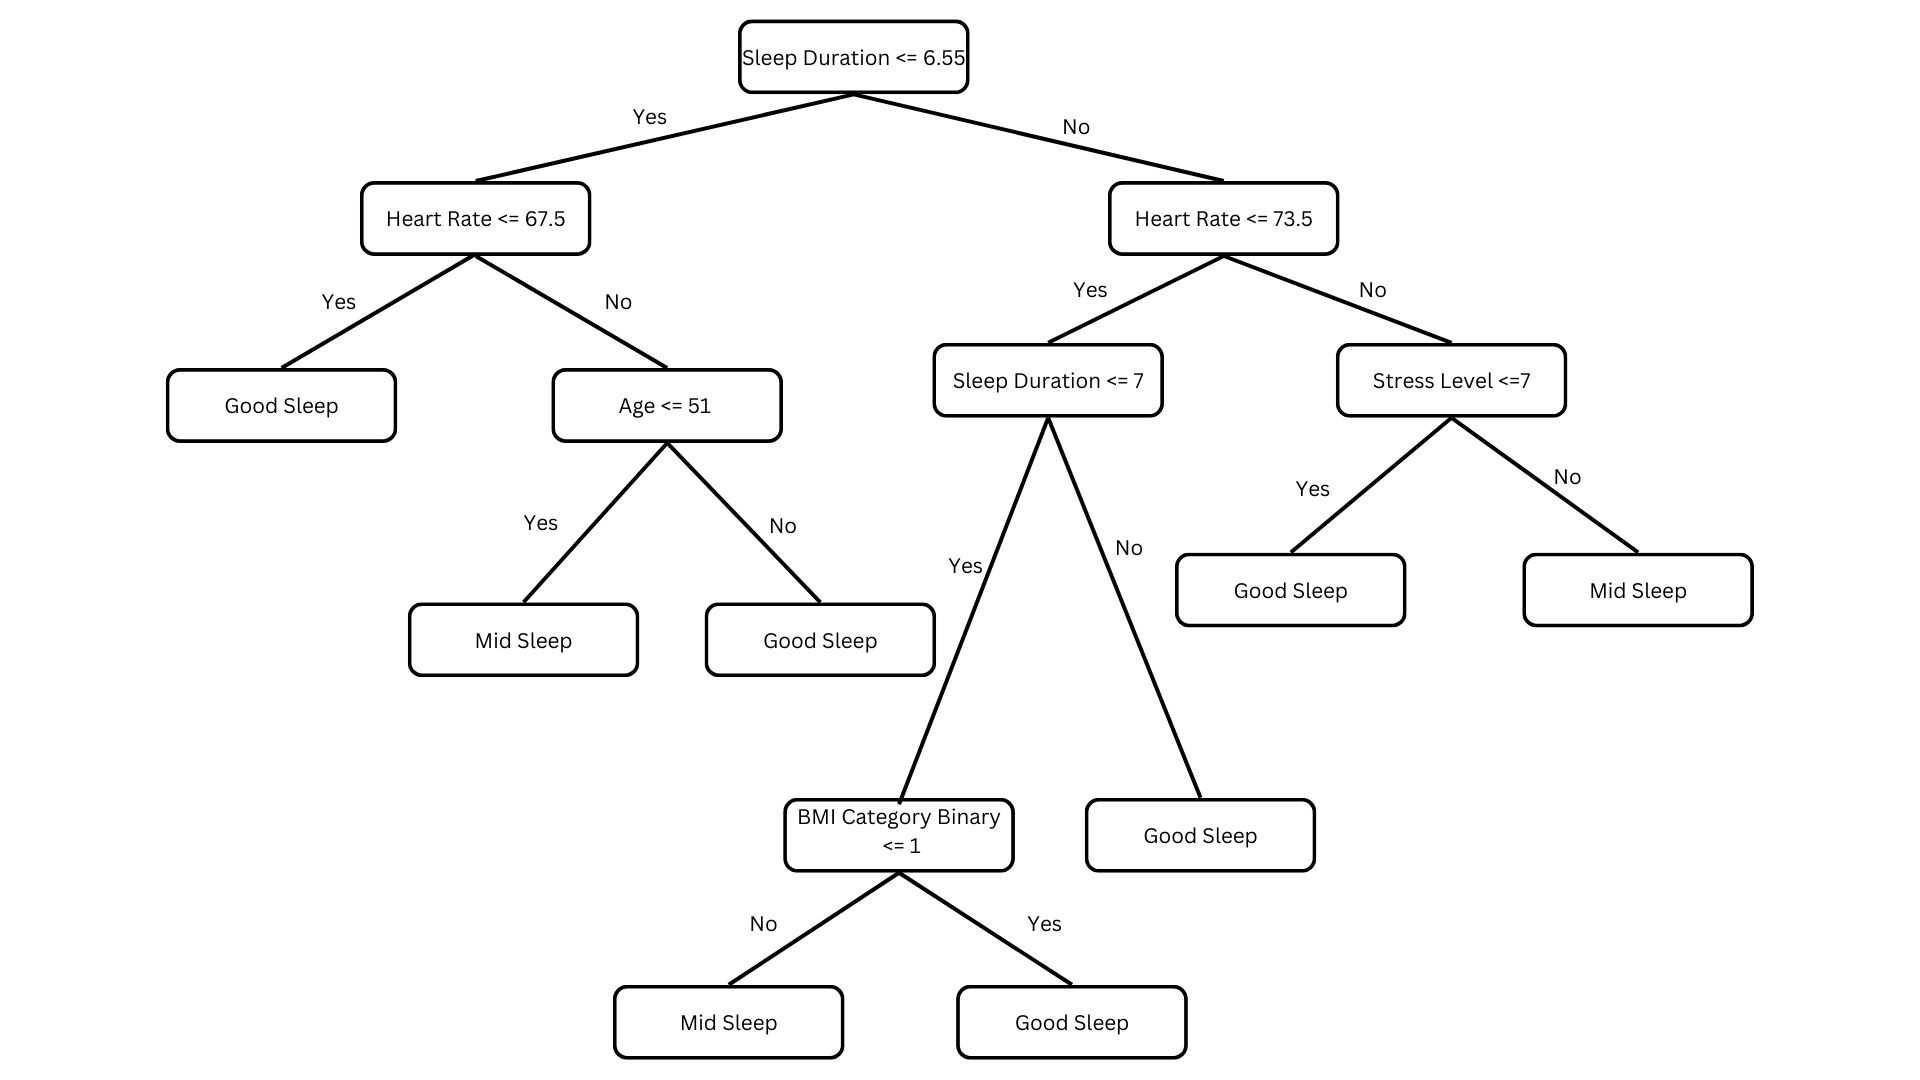

# Predicting the Best and Worst Case for Software Engineers

At this stage, I thought it would be an interesting idea to predict the maximum and minimum sleep quality for Software Engineers, based on the average stress level of individuals in this occupation. I am using the regression model, as it has proven to be an effective prediction tool for this dataset. The model is designed to identify the optimal conditions that would maximize the sleep quality of a Software Engineer, with the target set at 9.5.

In [20]:
occupation = "Software Engineer"
software_dev_data = data[data['Occupation'] == occupation]

if not software_dev_data.empty:
    software_dev_stress_level = software_dev_data['Stress Level'].mean()
else:
    raise ValueError(f"No data found for occupation: {occupation}")

# Define predictors (independent variables) and target (dependent variable)
X = data[['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', 'Heart Rate']]
y = data['Quality of Sleep']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Define a function to predict ideal conditions
def predict_ideal_conditions(model, stress_level, target_quality):

    optimal_conditions = {}

    # Define the range of possible values for predictors
    sleep_durations = np.linspace(6, 9, 100)  # Assume realistic sleep duration between 6 and 9 hours
    sleep_disorders = [0, 1]
    bmi_categories = [0, 1, 2]
    heart_rates = np.linspace(60, 100, 100)  # Assuming Heart Rate ranges from 60 to 100 bpm

    best_condition = None
    min_error = float('inf')

    # Iterate through combinations of predictors to find the best match
    for sleep_duration in sleep_durations:
        for sleep_disorder in sleep_disorders:
            for bmi_category in bmi_categories:
                for heart_rate in heart_rates:
                    # Construct feature vector as a DataFrame with correct column names
                    X = pd.DataFrame([[sleep_duration, stress_level, sleep_disorder, bmi_category, heart_rate]],
                                     columns=['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', 'Heart Rate'])

                    # Predict quality of sleep
                    predicted_quality = model.predict(X)[0]

                    # Check if the predicted quality is within the desired range
                    error = abs(predicted_quality - target_quality)
                    if error < min_error:
                        min_error = error
                        best_condition = {
                            'Sleep Duration': sleep_duration,
                            'Sleep Disorder': 'No' if sleep_disorder == 0 else 'Yes',
                            'BMI Category': ['Normal', 'Overweight', 'Obese'][bmi_category],
                            'Heart Rate': heart_rate,
                            'Predicted Quality of Sleep': predicted_quality
                        }

    return best_condition

# Predict ideal conditions for software developers to achieve a quality of 9-10
target_quality = 9.5  # Middle of the desired range (9-10)
ideal_conditions = predict_ideal_conditions(model, software_dev_stress_level, target_quality)

# Display results
print(f"Ideal Conditions for {occupation} to Achieve Sleep Quality of {target_quality}:\n")
for key, value in ideal_conditions.items():
    print(f"{key}: {value}")

Ideal Conditions for Software Engineer to Achieve Sleep Quality of 9.5:

Sleep Duration: 9.0
Sleep Disorder: No
BMI Category: Normal
Heart Rate: 60.0
Predicted Quality of Sleep: 8.585276422224554


As observed, the highest sleep quality a Software Engineer can achieve is 8.58. The optimal conditions for achieving this are 9 hours of sleep, no sleep disorders, a normal weight, and a heart rate of 60 bpm during sleep.

What the code does?

1. Calculate Average Stress Level for Specific Occupation (Software Engineer in this case):

- Filters rows where the 'Occupation' is 'Software Engineer' and calculates the average 'Stress Level'.
- Raises an error if no data exists for this occupation.
2. Define Predictors and Target:

- Uses variables like 'Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', and 'Heart Rate' as predictors (X).
Sets 'Quality of Sleep' as the target variable (y).
3. Split Data:

- Splits the data into training (80%) and testing (20%) sets to train and evaluate the regression model.
4. Train Regression Model:

- Trains a linear regression model on the training data.
5. Predict Optimal Conditions:

- Defines a function predict_ideal_conditions to find conditions (e.g., sleep duration, heart rate) that maximize sleep quality:
- Inputs:
 - stress_level: Average stress level for the user's occupation.
 - target_quality: Desired sleep quality (e.g., 9-10).
-Process:
 - Iterates over realistic values for predictors (e.g., sleep duration between 6–9 hours).
 - For each combination of conditions, predicts sleep quality using the trained model.
 - Tracks the combination that minimizes the error between predicted and target sleep quality.
- Outputs:
 - A dictionary of optimal conditions (e.g., best sleep duration, BMI category, and heart rate) to achieve the desired sleep quality.
6. Predict Ideal Conditions for Software Engineers:

- Uses the average stress level for software engineers to predict the optimal conditions to achieve a target sleep quality of 9.5.
- Displays the results, including predicted values for sleep duration, heart rate, BMI category, and more.

In this case, I aimed to do the opposite, predicting the realistic conditions that would result in the lowest possible quality of sleep for a Software Engineer, again using the regression model.

In [21]:
# Define predictors (independent variables) and target (dependent variable)
X = data[['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', 'Heart Rate']]
y = data['Quality of Sleep']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Calculate average stress level for software engineers
occupation = "Software Engineer"
software_dev_data = data[data['Occupation'] == occupation]  # Filter rows for software developers

if not software_dev_data.empty:
    software_dev_stress_level = software_dev_data['Stress Level'].mean()
else:
    raise ValueError(f"No data found for occupation: {occupation}")

# Define a function to predict worst conditions
def predict_worst_conditions(model, stress_level):

    # Define the range of possible values for predictors
    sleep_durations = np.linspace(6, 9, 100)  # Assume realistic sleep duration between 6 and 9 hours
    sleep_disorders = [0, 1]
    bmi_categories = [0, 1, 2]
    heart_rates = np.linspace(60, 100, 100)  # Assuming Heart Rate ranges from 60 to 100 bpm

    worst_condition = None
    lowest_quality = float('inf')  # Start with positive infinity to find the minimum

    # Iterate through combinations of predictors to find the worst match
    for sleep_duration in sleep_durations:
        for sleep_disorder in sleep_disorders:
            for bmi_category in bmi_categories:
                for heart_rate in heart_rates:
                    # Construct feature vector with correct feature names
                    X = pd.DataFrame([[sleep_duration, stress_level, sleep_disorder, bmi_category, heart_rate]],
                                     columns=['Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', 'Heart Rate'])

                    # Predict quality of sleep
                    predicted_quality = model.predict(X)[0]

                    # Check if the predicted quality is the lowest so far
                    if predicted_quality < lowest_quality:
                        lowest_quality = predicted_quality
                        worst_condition = {
                            'Sleep Duration': sleep_duration,
                            'Sleep Disorder': 'No' if sleep_disorder == 0 else 'Yes',
                            'BMI Category': ['Normal', 'Overweight', 'Obese'][bmi_category],
                            'Heart Rate': heart_rate,
                            'Predicted Quality of Sleep': predicted_quality
                        }

    return worst_condition

# Predict worst conditions for software developers
worst_conditions = predict_worst_conditions(model, software_dev_stress_level)

# Display results
print(f"Worst Conditions for {occupation} to Achieve Possible:\n")
for key, value in worst_conditions.items():
    print(f"{key}: {value}")

Worst Conditions for Software Engineer to Achieve Possible:

Sleep Duration: 6.0
Sleep Disorder: Yes
BMI Category: Obese
Heart Rate: 100.0
Predicted Quality of Sleep: 5.713723217202085


As observed, the worst sleep quality a Software Engineer can achieve is 5.71. The conditions leading to this outcome include 6 hours of sleep, the presence of sleep disorders, an obese BMI category, and a heart rate of 100 bpm during sleep.

What the Code Does:
1. Calculate Average Stress Level for Specific Occupation (Software Engineer):

- Filters the dataset to rows where 'Occupation' equals 'Software Engineer'.
- Calculates the mean 'Stress Level' for these rows.
- Raises an error if no data exists for this occupation.
2. Define Predictors and Target:

- Selects predictors (X) like 'Sleep Duration', 'Stress Level', 'Sleep Disorder Binary', 'BMI Category Numeric', and 'Heart Rate'.
- Sets 'Quality of Sleep' as the target variable (y).
3. Split Data:

- Splits the data into training (80%) and testing (20%) subsets to build and evaluate the model.
4. Train Regression Model:

- Fits a LinearRegression model to predict 'Quality of Sleep' using the training data.
5. Predict Worst Conditions:

- Implements the predict_worst_conditions function to find conditions that minimize sleep quality:
- Inputs:
 - The trained regression model.
 - The average stress level of software engineers.
- Process:
 - Iterates over realistic values for predictors (e.g., sleep duration: 6–9 hours, BMI categories: Normal, Overweight, Obese).
 - Predicts sleep quality for each combination using the trained model.
 - Tracks the combination that produces the lowest predicted sleep quality.
- Outputs:
 - A dictionary detailing the worst-case conditions, including sleep duration, BMI category, heart rate, and predicted quality of sleep.
- Predict Worst Conditions for Software Engineers:

 -  Uses the average stress level of software engineers as an input to predict the worst possible conditions for sleep quality.
 - Outputs and displays the results, showing the combination of factors leading to the lowest predicted sleep quality.

# Conclusion

This project aimed to explore the factors influencing sleep quality, focusing on gender, BMI, occupation, and health metrics such as stress levels, sleep disorders, and heart rate. Through data analysis and machine learning techniques, several key insights were uncovered.

The analysis revealed significant gender differences in sleep health. While women were found to have a higher likelihood of experiencing sleep disorders, they generally reported slightly better sleep quality and longer sleep durations compared to men. These findings align with existing research, which suggests that factors like hormonal cycles contribute to these differences. Moreover, higher stress levels in men appeared to explain their lower sleep quality despite similar rates of sleep disorders.

The relationship between BMI and sleep quality was also explored, and the results indicated that individuals with higher BMI categories tend to experience poorer sleep. This is consistent with established research suggesting that obesity can disrupt sleep patterns due to factors such as sleep apnea or metabolic changes.

The project further investigated the impact of occupation on sleep quality. Jobs with high stress levels, such as those in sales, were found to negatively affect sleep, while professions like software engineering, despite their stress levels, showed more consistent patterns of sleep quality and duration. Additionally, the predictive power of regression models was demonstrated, showing how sleep quality can be forecasted based on factors like sleep duration, stress levels, and BMI.

For software engineers, the project predicted the best achievable sleep quality to be 8.58, with optimal conditions being 9 hours of sleep, no sleep disorders, normal weight, and a heart rate of 60 bpm during sleep. In contrast, the worst achievable sleep quality was 5.71, resulting from 6 hours of sleep, the presence of sleep disorders, obesity, and a heart rate of 100 bpm.

This project has provided valuable insights into the complex relationships between lifestyle factors, health metrics, and sleep quality. It underscores the importance of maintaining a balanced lifestyle and managing stress for optimal sleep health. The findings also highlight the need for tailored recommendations based on individual circumstances, such as occupation and BMI category, to improve sleep quality.

Looking forward, I aim to work with larger datasets to refine predictions and develop more accurate and robust predictive models. A larger sample size would provide a better understanding of these complex relationships, enabling more personalized recommendations for improving sleep health.